In [3]:
# 셀 1: 환경 설정 + import
import os
import sys
import sqlite3
from dotenv import load_dotenv

load_dotenv()

print(f"Python : {sys.version}")
print(f"OPENAI_API_KEY : {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정 ⚠️'}")
print(f"BYBIT_API_KEY  : {'설정됨' if os.getenv('BYBIT_API_KEY')  else '미설정 (샘플 모드)'}")

Python : 3.13.12 (main, Mar 10 2026, 18:26:32) [Clang 21.1.4 ]
OPENAI_API_KEY : 설정됨
BYBIT_API_KEY  : 설정됨


In [4]:
# 셀 2: 그래프 + DEFAULT_STATE 임포트
from graph import graph, DEFAULT_STATE

print("graph       :", graph)
print("state keys  :", list(DEFAULT_STATE.keys()))

/Users/kieokkim/Desktop/03_AIAgents/03_Langgraph/trade-coach/.venv/lib/python3.13/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
INFO:db:get_db: opening connection to /Users/kieokkim/Desktop/03_AIAgents/03_Langgraph/trade-coach/tradecoach.db
INFO:db:get_db: commit ok
INFO:db:get_db: connection closed


graph       : <langgraph.graph.state.CompiledStateGraph object at 0x118c94ad0>
state keys  : ['session_id', 'input_type', 'journal_data', 'chart_image', 'stats', 'weaknesses', 'past_weaknesses', 'chart_feedback', 'current_concept', 'quiz_question', 'quiz_answer', 'quiz_result', 'retry_count', 'trade_count', 'improvement_log', 'messages', 'setup_analysis', 'action_rule', 'avg_return_rate', 'expected_value', 'loss_consistency', 'concept_not_found', 'last_fetched_at', 'has_new_data', 'raw_trades', 'journal_entries', 'performance_summary', 'coaching_output', 'fallback_type']


DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): mermaid.ink:443
DEBUG:urllib3.connectionpool:https://mermaid.ink:443 "GET /img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyg8cD5fX3N0YXJ0X188L3A+KQoJbWVtb3J5X2xvYWQobWVtb3J5X2xvYWQpCgluZXdfZGF0YV9jaGVjayhuZXdfZGF0YV9jaGVjaykKCWJ5Yml0X2ZldGNoKGJ5Yml0X2ZldGNoKQoJcHJlcHJvY2VzcyhwcmVwcm9jZXNzKQoJam91cm5hbF93cml0ZShqb3VybmFsX3dyaXRlKQoJaW5wdXRfcm91dGVyKGlucHV0X3JvdXRlcikKCWpvdXJuYWxfYW5hbHlzaXMoam91cm5hbF9hbmFseXNpcykKCXBlcmZvcm1hbmNlX2FuYWx5c2lzKHBlcmZvcm1hbmNlX2FuYWx5c2lzKQoJd2Vha25lc3NfZGV0ZWN0KHdlYWtuZXNzX2RldGVjdCkKCWZhbGxiYWNrX2NsYXNzaWZ5KGZhbGxiYWNrX2NsYXNzaWZ5KQoJYmFja3Rlc3RfY29hY2goYmFja3Rlc3RfY29hY2gpCglxdWl6X2dlbmVyYXRlKHF1aXpfZ2VuZXJhdGUpCgltZW1vcnlfc2F2ZShtZW1vcnlfc2F2ZSkKCV9fZW5kX18oPHA+X19lbmRfXzwvcD4pCglfX3N0YXJ0X18gLS0+IG1lbW9yeV9sb2FkOwoJYmFja3Rlc3RfY29hY2ggLS0+IHF1aXpfZ2VuZXJhdGU7CglieWJpdF9mZXRjaCAtLT4gcHJlcHJvY2VzczsKCWZhbGxiYWNrX2NsYXNzaWZ5IC0uLT4gYmFja3Rlc3RfY

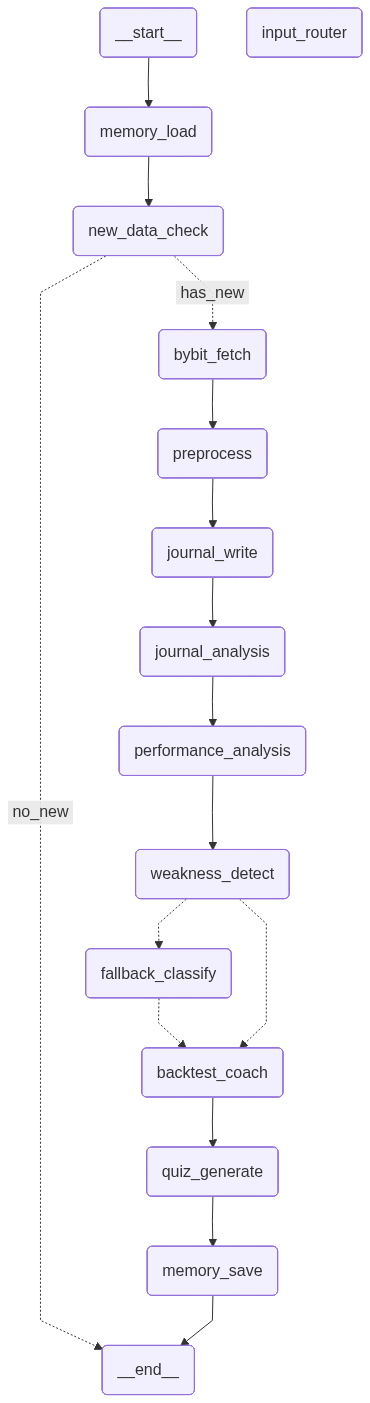

In [5]:
# 셀 3: 그래프 시각화
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [6]:
# 셀 4: 한 사이클 실행
result = graph.invoke({
    **DEFAULT_STATE,
    "session_id": "demo",
    "input_type": "bybit",
    "journal_data": "",
    "raw_trades": [],
})
print("실행 완료")

INFO:db:get_db: opening connection to /Users/kieokkim/Desktop/03_AIAgents/03_Langgraph/trade-coach/tradecoach.db
INFO:db:get_db: commit ok
INFO:db:get_db: connection closed
INFO:nodes.fetch_nodes:new_data_check_node start | session_id=demo
INFO:nodes.fetch_nodes:new_data_check_node: first run, has_new_data=True | session_id=demo
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): api.bybit.com:443
DEBUG:urllib3.connectionpool:https://api.bybit.com:443 "GET /v5/execution/list?category=linear&limit=50 HTTP/1.1" 200 125
INFO:nodes.fetch_nodes:bybit_fetch_node: API response retCode=0
INFO:nodes.fetch_nodes:bybit_fetch_node: no trades from API, loading sample_trades.json
INFO:nodes.fetch_nodes:bybit_fetch_node end | session_id=demo trades=20
INFO:nodes.preprocess_nodes:preprocess_node start | session_id=demo
INFO:nodes.preprocess_nodes:preprocess_node bybit: normalized 10 closed trades | session_id=demo
INFO:nodes.preprocess_nodes:preprocess_node end | session_id=demo
INFO:nodes

실행 완료


In [7]:
# 셀 5: 결과 출력
stats = result.get("stats", {})

print("=" * 60)
print("[KPI]")
print(f"  win_rate         : {stats.get('win_rate', 0):.1%}")
print(f"  avg_return_rate  : {stats.get('avg_return_rate', 0):.2f}%")
print(f"  expected_value   : {stats.get('expected_value', 0):.2f}%")
print(f"  loss_consistency : {stats.get('loss_consistency', 0):.2f}")

print("\n[약점 태그]")
weaknesses = result.get("weaknesses", [])
if weaknesses:
    for w in weaknesses:
        print(f"  • {w}")
else:
    print("  (없음)")

print("\n[action_rule]")
print(f"  {result.get('action_rule', '(없음)')}")

print("\n[코칭 결과]")
coaching = result.get("coaching_output", "")
print(coaching if coaching else "  (없음)")
print("=" * 60)

[KPI]
  win_rate         : 60.0%
  avg_return_rate  : 1.62%
  expected_value   : 1.62%
  loss_consistency : 0.15

[약점 태그]
  • BTC_개선필요

[action_rule]
  BTC 셋업에서는 절대 진입하지 마세요.

[코칭 결과]
BTC에서의 개선 필요성은 비효율적인 거래 결정으로 나타났습니다. 예를 들어, 시장의 변동성을 무시하고 진입 시점을 잘못 판단하여 손실을 초래했습니다. 이를 해결하기 위해 'ICT의 시장 구조 분석'을 활용한 백테스트 전략을 제안합니다. 특정 가격대에서의 반전 패턴을 찾아 매수/매도 신호를 생성하는 것입니다.

내일 실행할 규칙은 1) 비트코인 가격이 특정 지지선 아래로 하락할 경우 매도 포지션을 고려하고, 2) 시장 심리를 분석하여 과매도/과매수 구간에서 진입 결정을 내리는 것입니다.

추가 약점으로는 감정적 결정과 리스크 관리 부족이 있습니다. 감정적 결정은 손실을 확대시키고, 리스크 관리는 자본 보호에 필수적입니다.


In [8]:
# 셀 6: QA assert (D7-3)

# 환경 체크
assert graph is not None, "그래프 컴파일 실패"

# 저널 분석 플로우
result = graph.invoke({
    **DEFAULT_STATE,
    "session_id": "qa_test",
    "input_type": "bybit",
    "journal_data": "",
    "raw_trades": [],
})
assert "win_rate" in result.get("stats", {}), "win_rate 없음"
assert "avg_return_rate" in result.get("stats", {}), "avg_return_rate 없음"
assert "expected_value" in result.get("stats", {}), "expected_value 없음"
assert "loss_consistency" in result.get("stats", {}), "loss_consistency 없음"
assert result.get("action_rule", "") != "", "action_rule 비어있음"
print("✅ 저널 분석 PASS")

# 메모리 영속성
conn = sqlite3.connect("tradecoach.db")
rows = conn.execute(
    "SELECT avg_return_rate, expected_value, loss_consistency FROM trade_history ORDER BY id DESC LIMIT 1"
).fetchone()
assert rows is not None, "trade_history 저장 안됨"
conn.close()
print("✅ 메모리 영속성 PASS")

# 엣지 케이스
result_empty = graph.invoke({
    **DEFAULT_STATE,
    "last_fetched_at": "2099-01-01",
    "input_type": "bybit",
})
assert result_empty.get("has_new_data") == False, "신규 없음 분기 실패"
print("✅ 엣지 케이스 PASS")

print("\n🎉 전체 QA 통과")

INFO:db:get_db: opening connection to /Users/kieokkim/Desktop/03_AIAgents/03_Langgraph/trade-coach/tradecoach.db
INFO:db:get_db: commit ok
INFO:db:get_db: connection closed
INFO:nodes.fetch_nodes:new_data_check_node start | session_id=qa_test
INFO:nodes.fetch_nodes:new_data_check_node: first run, has_new_data=True | session_id=qa_test
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): api.bybit.com:443
DEBUG:urllib3.connectionpool:https://api.bybit.com:443 "GET /v5/execution/list?category=linear&limit=50 HTTP/1.1" 200 125
INFO:nodes.fetch_nodes:bybit_fetch_node: API response retCode=0
INFO:nodes.fetch_nodes:bybit_fetch_node: no trades from API, loading sample_trades.json
INFO:nodes.fetch_nodes:bybit_fetch_node end | session_id=qa_test trades=20
INFO:nodes.preprocess_nodes:preprocess_node start | session_id=qa_test
INFO:nodes.preprocess_nodes:preprocess_node bybit: normalized 10 closed trades | session_id=qa_test
INFO:nodes.preprocess_nodes:preprocess_node end | session_id=

✅ 저널 분석 PASS
✅ 메모리 영속성 PASS
✅ 엣지 케이스 PASS

🎉 전체 QA 통과
